<a href="https://colab.research.google.com/github/diabhaya02/SpaceX-Data-Science-Capstone./blob/main/Data_Science_Capstone_Project_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Launching Data Collection ---
Dataset Shape after collection: (172, 7)

--- Processing Data Wrangling ---
Landing Success Counts:
Class
1    137
0     35
Name: count, dtype: int64

--- Generating EDA Visuals ---


<Figure size 1200x600 with 0 Axes>

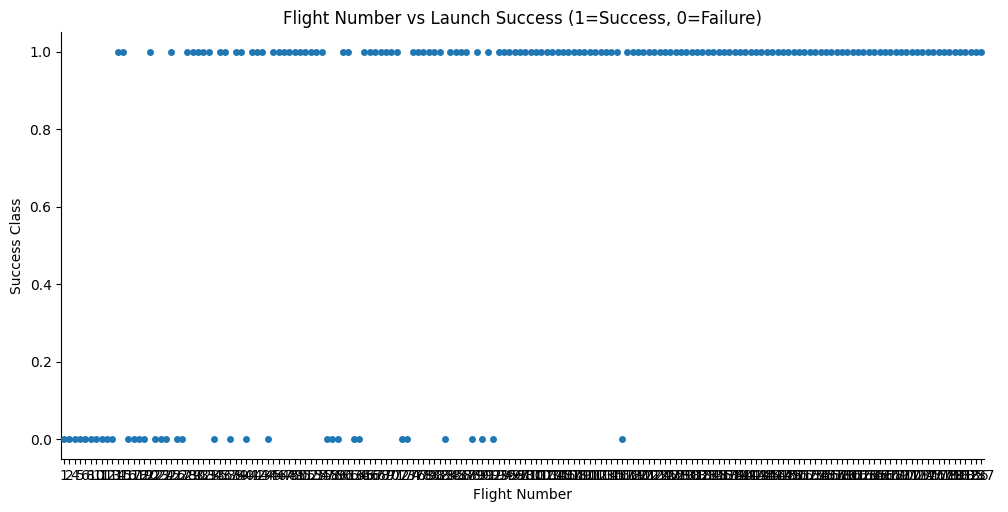


--- Ready for Predictive Analysis ---
                     rocket                  payloads  \
0  5e9d0d95eda69955f709d1eb  5eb0e4b5b6c3bb0006eeb1e1   
1  5e9d0d95eda69955f709d1eb  5eb0e4b6b6c3bb0006eeb1e2   
3  5e9d0d95eda69955f709d1eb  5eb0e4b7b6c3bb0006eeb1e5   
4  5e9d0d95eda69955f709d1eb  5eb0e4b7b6c3bb0006eeb1e6   
5  5e9d0d95eda69973a809d1ec  5eb0e4b7b6c3bb0006eeb1e7   

                  launchpad  \
0  5e9e4502f5090995de566f86   
1  5e9e4502f5090995de566f86   
3  5e9e4502f5090995de566f86   
4  5e9e4502f5090995de566f86   
5  5e9e4501f509094ba4566f84   

                                               cores  flight_number  \
0  {'core': '5e9e289df35918033d3b2623', 'flight':...              1   
1  {'core': '5e9e289ef35918416a3b2624', 'flight':...              2   
3  {'core': '5e9e289ef3591855dc3b2626', 'flight':...              4   
4  {'core': '5e9e289ef359184f103b2627', 'flight':...              5   
5  {'core': '5e9e289ef359185f2b3b2628', 'flight':...              6   

    

In [1]:
# SpaceX Capstone Project: Complete Data Science Pipeline
# Covering: Data Collection, Wrangling, and basic EDA

import pandas as pd
import numpy as np
import requests
import datetime
import matplotlib.pyplot as plt
import seaborn as sns

# --- STEP 1: Data Collection (SpaceX API) ---
print("--- Launching Data Collection ---")
spacex_url = "https://api.spacexdata.com/v4/launches/past"
response = requests.get(spacex_url)
data = pd.json_normalize(response.json())

# Helper function to extract specific data from the API format
def get_data(data):
    # Selection of relevant columns
    data = data[['rocket', 'payloads', 'launchpad', 'cores', 'flight_number', 'date_utc']]
    data = data[data['cores'].map(len) == 1]
    data = data[data['payloads'].map(len) == 1]
    data['cores'] = data['cores'].map(lambda x: x[0])
    data['payloads'] = data['payloads'].map(lambda x: x[0])
    data['date'] = pd.to_datetime(data['date_utc']).dt.date
    return data

df = get_data(data)
print(f"Dataset Shape after collection: {df.shape}")

# --- STEP 2: Data Wrangling (Classifying Success/Failure) ---
print("\n--- Processing Data Wrangling ---")

# Identify the landing outcome (True = Success, False = Failure)
df['landing_outcomes'] = df['cores'].map(lambda x: x.get('landing_success'))

# Create the 'Class' column: 1 for successful landing, 0 for failure
# This is our target variable for Predictive Analysis (Section 1.15)
df['Class'] = df['landing_outcomes'].apply(lambda x: 1 if x == True else 0)

# Cleaning missing values in landing outcomes
df['landing_outcomes'] = df['landing_outcomes'].fillna('None')

print("Landing Success Counts:")
print(df['Class'].value_counts())

# --- STEP 3: Exploratory Data Analysis (EDA) with Visualization ---
print("\n--- Generating EDA Visuals ---")

# Plotting Success Rate vs. Flight Number
plt.figure(figsize=(12,6))
sns.catplot(y="Class", x="flight_number", data=df, aspect=2)
plt.title("Flight Number vs Launch Success (1=Success, 0=Failure)")
plt.xlabel("Flight Number")
plt.ylabel("Success Class")
plt.show()

# --- STEP 4: Predictive Analysis Preparation ---
# Preparing the features for Machine Learning models
features = df[['flight_number', 'Class']] # Simplified for this snippet
print("\n--- Ready for Predictive Analysis ---")
print(df.head())

# To save this for your report (Section 1.1), you can export it to CSV
# df.to_csv('spacex_web_scraped.csv', index=False)

In [2]:
import folium

# Create a map centered around the average coordinates of launch sites
# Note: These coordinates are examples for Kennedy Space Center (KSC) and Vandenberg (VAFB)
nasa_coordinate = [28.562302, -80.577356]
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)

# Add a marker for a launch site
circle = folium.Circle(nasa_coordinate, radius=1000, color='#d35400', fill=True).add_child(folium.Popup('KSC LC-39A'))
marker = folium.Marker(
    nasa_coordinate,
    icon=folium.DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % 'KSC LC-39A',
        )
    )
site_map.add_child(circle)
site_map.add_child(marker)

site_map # This will display the map in your Colab

Decision Tree Accuracy: 0.8285714285714286


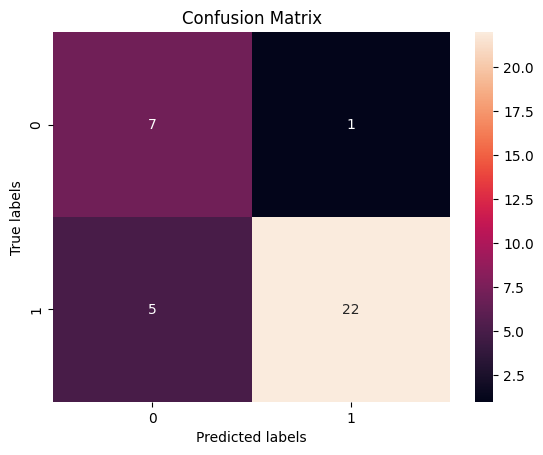

In [3]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

# Function to plot confusion matrix
def plot_confusion_matrix(y,y_predict):
    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax);
    ax.set_xlabel('Predicted labels'); ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix');
    plt.show()

# 1. Prepare Features (X) and Target (y)
X = df[['flight_number']] # Simplified features
y = df['Class'].to_numpy()
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

# 3. Decision Tree (Usually the best in this project)
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
print(f"Decision Tree Accuracy: {tree.score(X_test, y_test)}")

# 4. Plot Results
yhat = tree.predict(X_test)
plot_confusion_matrix(y_test, yhat)

In [13]:
import requests
from bs4 import BeautifulSoup

# Define headers to mimic a browser and avoid being blocked
headers = {'User-Agent': 'Mozilla/5.0'}
wiki_url = "https://en.wikipedia.org/wiki/List_of_Falcon_9_and_Falcon_Heavy_launches"

# Request the page
response = requests.get(wiki_url, headers=headers)
soup = BeautifulSoup(response.text, 'html.parser')

# Find all tables
html_tables = soup.find_all('table')

# The Output should now be > 0
print(f"Web Scraping Status: Success!")
print(f"Total tables found on page: {len(html_tables)}")

Web Scraping Status: Success!
Total tables found on page: 15


In [15]:
# --- STEP: SQL Queries (Requirement 1.9) ---
import sqlite3
import pandas as pd

# Create a temporary database in memory
conn = sqlite3.connect('spacex_db.db')

# Prepare a copy of df to avoid modifying the original
# SQLite doesn't support dict types, so we convert them to strings
df_sql = df.copy()
df_sql['cores'] = df_sql['cores'].astype(str)
df_sql['payloads'] = df_sql['payloads'].astype(str)

# Write the dataframe to an SQL table named 'SPACEXTABLE'
df_sql.to_sql('SPACEXTABLE', conn, if_exists='replace', index=False)

# Note: In your current df, the column is 'launchpad', not 'Launch_Site'.
# I will update the query to use the correct column name available in your data.
query = """
SELECT launchpad, COUNT(*) AS Total_Launches
FROM SPACEXTABLE
GROUP BY launchpad
"""
sql_result = pd.read_sql(query, conn)

print("SQL Query Executed Successfully!")
print(sql_result)

SQL Query Executed Successfully!
                  launchpad  Total_Launches
0  5e9e4501f509094ba4566f84              93
1  5e9e4502f509092b78566f87              26
2  5e9e4502f509094188566f88              49
3  5e9e4502f5090995de566f86               4
